# Three Stage Model

1. Classification step 1: Carbon or Nitrogen (binary)
2. Classification step 2: Which carbon or which nitrogen source (multiclass)
3. Regression: Predict uptake of present nutrients

*previous implementations have revealed that the model is essentially just predicting 0/absence because targets are zero-inflated*

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import plotly.express as px

In [16]:
# from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.pipeline import Pipeline

# Loss metric:
from sklearn.metrics import mean_squared_error as mse

# evaluation:
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import confusion_matrix, accuracy_score, multilabel_confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

# data prep and plotting etc:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

### Load Data

In [5]:
train_data = pd.read_pickle(DATA/"ml_datasets/TRAIN_raw.pkl")
features = pd.read_pickle(DATA/"ml_datasets/L2_FEATURES_ML.pkl")

rxn_cols = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e','EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

In [10]:
target = train_data[rxn_cols]
target = (-target.clip(upper=0))
target[target == 0] = 0 # to avoid negative

target['source'] = train_data['source']
target['source_type'] = target['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

**SPLIT -> TRAIN AND VALIDATION**

In [12]:
X = features.copy()
Y = target.copy()

In [39]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['source'])

### Target distribution

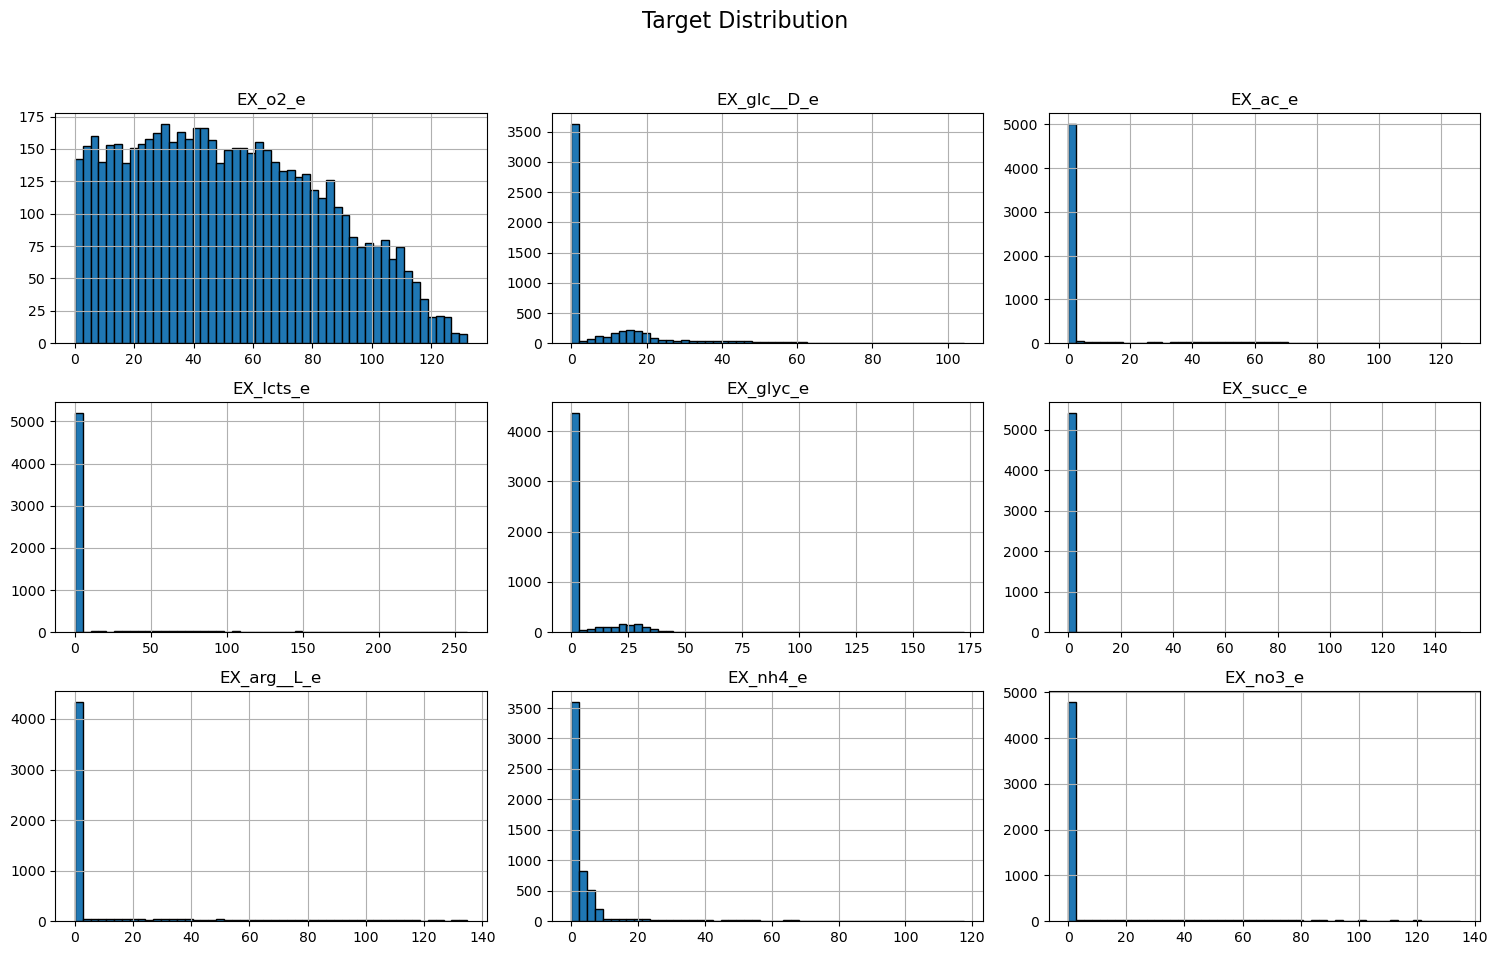

In [20]:
target.iloc[:, :9].hist(bins=50, figsize=(15, 10), layout=(-1, 3), edgecolor='black')

plt.suptitle('Target Distribution', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

## 1.1 - Defining Targets for Each Stage

In [41]:
Y_train_type = Y_train['source_type']
Y_val_type = Y_val['source_type']

le_type = LabelEncoder()
Y_train_type = le_type.fit_transform(Y_train_type)
Y_val_type = le_type.transform(Y_val_type)

##################################################
Y_train_num = Y_train.iloc[:, :9]
Y_val_num = Y_val.iloc[:, :9]

**For separate source-specific classifiers:**

In [44]:
# Stage 2: specific source
Y_train_source = Y_train['source']
Y_val_source = Y_val['source']

# masks from source_type, not source
c_mask_train = (Y_train['source_type'] == "carbon")
c_mask_val = (Y_val['source_type'] == "carbon")
n_mask_train = (Y_train['source_type'] == "nitrogen")
n_mask_val = (Y_val['source_type'] == "nitrogen")

# subset X
X_train_c = X_train[c_mask_train]
X_val_c = X_val[c_mask_val]
X_train_n = X_train[n_mask_train]
X_val_n = X_val[n_mask_val]

# subset source labels
Y_train_c = Y_train_source[c_mask_train]
Y_val_c = Y_val_source[c_mask_val]
Y_train_n = Y_train_source[n_mask_train]
Y_val_n = Y_val_source[n_mask_val]

# separate encoders
le_carbon = LabelEncoder()
le_nitrogen = LabelEncoder()

Y_train_c_enc = le_carbon.fit_transform(Y_train_c)
Y_val_c_enc = le_carbon.transform(Y_val_c)

Y_train_n_enc = le_nitrogen.fit_transform(Y_train_n)
Y_val_n_enc = le_nitrogen.transform(Y_val_n)

## 2. - Training Each Model

### 2.1 - Type Classifier (Carbon or Nitrogen)

In [27]:
binary_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

binary_clf.fit(X_train, Y_train_type)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 2.2 - Source Classifiers

In [29]:
carbon_mask_train = (Y_train_source == "carbon")
nitrogen_mask_train = (Y_train_source == "nitrogen")

carbon_mask_val = (Y_val_source == "carbon")
nitrogen_mask_val = (Y_val_source == "nitrogen")

In [ ]:
Y_train_c = Y_train_source[carbon_mask_train]
Y_val_c = Y_val_source[carbon_mask_val]

Y_train_n = Y_train_source[nitrogen_mask_train]
Y_val_n = Y_val_source[nitrogen_mask_val]

In [ ]:
carbon_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

nitrogen_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

carbon_clf.fit(X_train[carbon_mask], Y_train_s)